# Classification des pannes PV — LightGBM

Détection du type de panne (16 classes : F0 à F7, variantes **L** et **M**) à partir des signaux capteurs (Ipv, Vpv, Vdc, courants/tensions abc, ...).

**Avant de lancer :** dépose tous tes fichiers `F*.csv` dans un dossier sur ton Google Drive et renseigne son chemin dans la cellule de configuration ci-dessous.

## 1. Connexion à Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Installation / imports

In [ ]:
!pip install -q lightgbm

import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)

sns.set_theme(style="whitegrid")


## 3. Configuration

Modifie `DATA_DIR` pour pointer vers le dossier Drive contenant tes fichiers `F*.csv` (ex: `F0L.csv`, `F0M.csv`, ..., `F7M.csv`).

In [ ]:
DATA_DIR = "/content/drive/MyDrive/projet_Paneau_solaire"   # <-- à adapter
OUTPUT_DIR = "/content/drive/MyDrive/resultat_projet_panneau_solaire"   # dossier où sauvegarder le modèle
os.makedirs(OUTPUT_DIR, exist_ok=True)

TIME_COL = "Time"   # colonne à exclure des features (non generalisable)


## 4. Chargement et labellisation des données

In [ ]:
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "F*.csv")))
print(f"{len(csv_files)} fichiers trouvés")
assert len(csv_files) > 0, "Aucun fichier F*.csv trouvé dans DATA_DIR — vérifie le chemin."

dfs = []
for f in csv_files:
    fname = os.path.basename(f)
    match = re.match(r"F(\d)([A-Za-z])", fname)
    if not match:
        print(f"⚠️ Nom de fichier inattendu, ignoré : {fname}")
        continue
    label = f"{match.group(1)}{match.group(2).upper()}"   # ex: "7M", "0L"
    df = pd.read_csv(f)
    df["label"] = label
    df["source_file"] = fname
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print("Shape totale :", data.shape)
data.head()


16 fichiers trouvés
Shape totale : (2163480, 16)


,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,Iabc,If,Vabc,Vf,label,source_file
0,0.000028,1.572327,101.348877,144.140625,-0.135133,0.490112,-0.354985,41.744537,-149.872894,109.064585,1.0,50.0,1.0,50.0,0L,F0L.csv
1,0.000128,1.503265,101.458740,143.554688,-0.108277,0.510254,-0.388555,46.831512,-150.716705,105.829976,1.0,50.0,1.0,50.0,0L,F0L.csv
2,0.000228,1.492859,101.574707,143.554688,-0.168702,0.496826,-0.334844,51.074677,-152.018585,102.543132,1.0,50.0,1.0,50.0,0L,F0L.csv
3,0.000328,1.558136,101.312256,143.261719,-0.135133,0.510254,-0.361699,55.848236,-152.585144,98.143260,1.0,50.0,1.0,50.0,0L,F0L.csv
4,0.000428,1.631927,101.141357,143.847656,-0.202271,0.503540,-0.321416,60.055237,-152.609253,94.261729,1.0,50.0,1.0,50.0,0L,F0L.csv


## 5. Aperçu du dataset

label
0L    143715
0M    141014
1L    129013
1M    139014
2L    142128
2M    144015
3L    103497
3M     69967
4L    144014
4M    144014
5L    143015
5M    144014
6L    144015
6M    144015
7L    144015
7M    144015
Name: count, dtype: int64


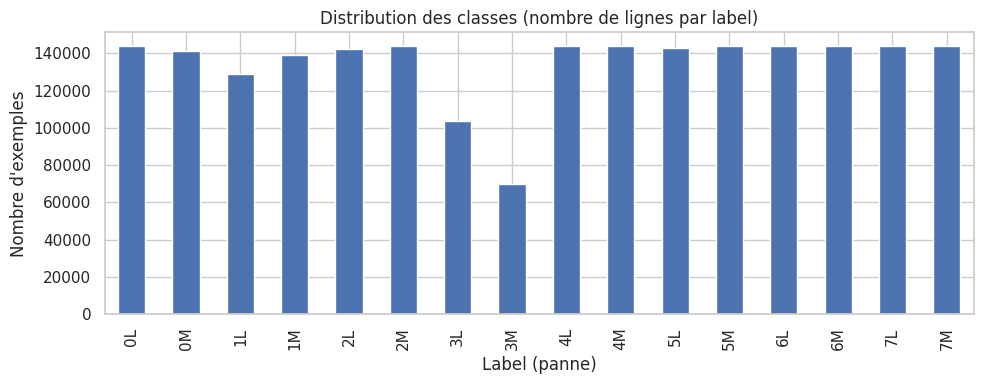

In [ ]:
print(data["label"].value_counts().sort_index())

plt.figure(figsize=(10, 4))
data["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution des classes (nombre de lignes par label)")
plt.xlabel("Label (panne)")
plt.ylabel("Nombre d'exemples")
plt.tight_layout()
plt.show()


In [ ]:
data.info()
data.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2163480 entries, 0 to 2163479
Data columns (total 16 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Time         float64
 1   Ipv          float64
 2   Vpv          float64
 3   Vdc          float64
 4   ia           float64
 5   ib           float64
 6   ic           float64
 7   va           float64
 8   vb           float64
 9   vc           float64
 10  Iabc         float64
 11  If           float64
 12  Vabc         float64
 13  Vf           float64
 14  label        object 
 15  source_file  object 
dtypes: float64(14), object(2)
memory usage: 264.1+ MB


,count,mean,std,min,25%,50%,75%,max
Time,2163480.0,6.901942,4.082440,3.900159e-06,3.379926,6.759857,10.349404,14.399999
Ipv,2163480.0,1.777343,0.603385,-5.950623e-01,1.463531,1.791809,2.283752,11.208740
Vpv,2163480.0,88.102688,23.242385,-1.655884e+01,87.005615,91.314697,101.397705,111.474609
Vdc,2163480.0,139.390992,27.331583,0.000000e+00,143.261719,144.433594,147.363281,253.710938
ia,2163480.0,-0.021031,0.572083,-6.358888e+00,-0.383546,-0.014283,0.341552,13.769286
ib,2163480.0,0.001564,0.575703,-7.297974e+00,-0.335693,0.006714,0.355835,6.828003
ic,2163480.0,-0.023723,0.563751,-1.285621e+01,-0.348271,-0.032720,0.323115,6.358882
va,2163480.0,0.839021,109.873088,-1.622046e+02,-108.996277,0.843811,110.695953,161.204071
vb,2163480.0,0.821966,109.874972,-1.622046e+02,-109.020386,0.807648,110.683899,161.204071
vc,2163480.0,0.825676,109.860881,-1.600348e+02,-109.056549,0.783539,110.659790,160.211589


## 6. Matrice de corrélation

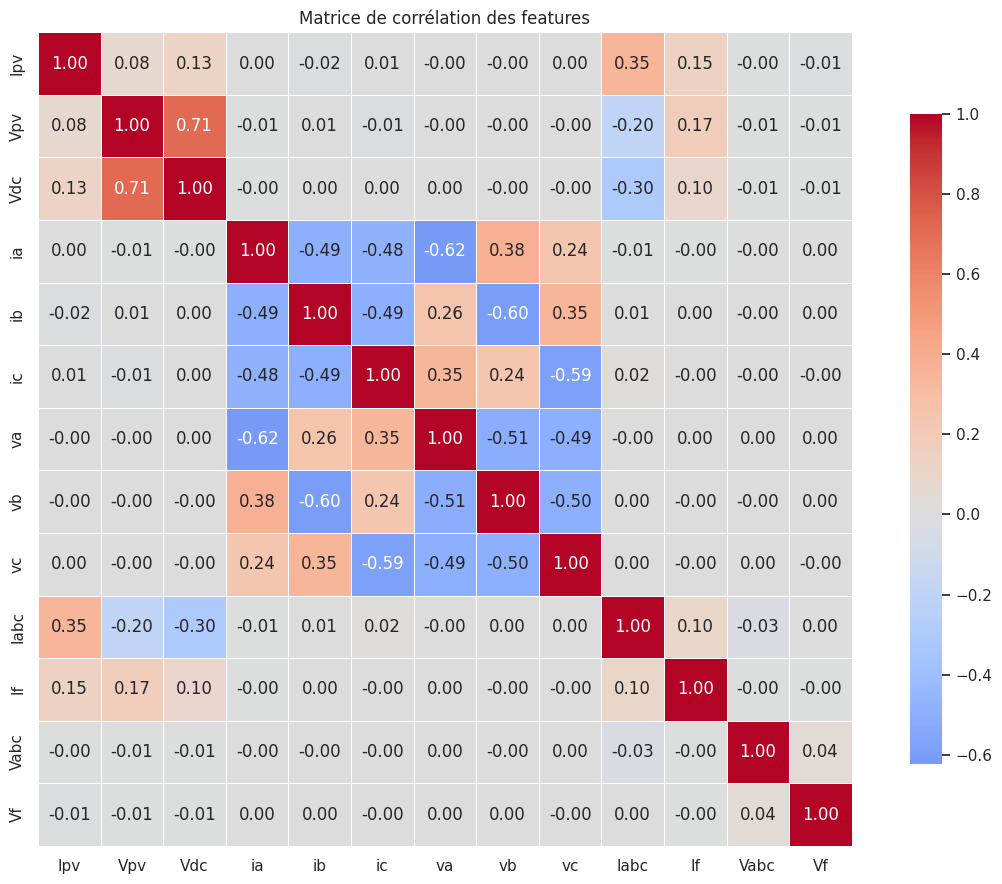

In [ ]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if TIME_COL in numeric_cols:
    numeric_cols.remove(TIME_COL)

corr = data[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation des features")
plt.tight_layout()
plt.show()


## 7. Préparation des features et des labels

On retire `Time` (non généralisable d'un fichier à l'autre) et les colonnes non numériques utilisées uniquement pour le suivi (`label`, `source_file`).

In [ ]:
drop_cols = [TIME_COL, "label", "source_file"]
feature_cols = [c for c in data.columns if c not in drop_cols]

X = data[feature_cols].copy()
y_raw = data["label"].copy()

print("Features utilisées :", feature_cols)

le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Classes :", list(le.classes_))
print("Nombre de classes :", len(le.classes_))


Features utilisées : ['Ipv', 'Vpv', 'Vdc', 'ia', 'ib', 'ic', 'va', 'vb', 'vc', 'Iabc', 'If', 'Vabc', 'Vf']
Classes : ['0L', '0M', '1L', '1M', '2L', '2M', '3L', '3M', '4L', '4M', '5L', '5M', '6L', '6M', '7L', '7M']
Nombre de classes : 16


## 8. Split train / test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train :", X_train.shape, " Test :", X_test.shape)


Train : (1730784, 13)  Test : (432696, 13)


## 9. Entraînement LightGBM

In [ ]:
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    "objective": "multiclass",
    "num_class": len(le.classes_),
    "metric": "multi_logloss",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "is_unbalance": True,     # utile si certaines classes (ex: F0 = pas d'erreur) sont surreprésentées
    "verbose": -1,
    "seed": 42,
}

evals_result = {}

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, val_data],
    valid_names=["train", "valid"],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50),
        lgb.record_evaluation(evals_result),
    ],
)


Training until validation scores don't improve for 50 rounds
[50]	train's multi_logloss: 0.221662	valid's multi_logloss: 0.224458
[100]	train's multi_logloss: 0.126713	valid's multi_logloss: 0.130728
[150]	train's multi_logloss: 0.470187	valid's multi_logloss: 0.48331
Early stopping, best iteration is:
[129]	train's multi_logloss: 0.105975	valid's multi_logloss: 0.111435


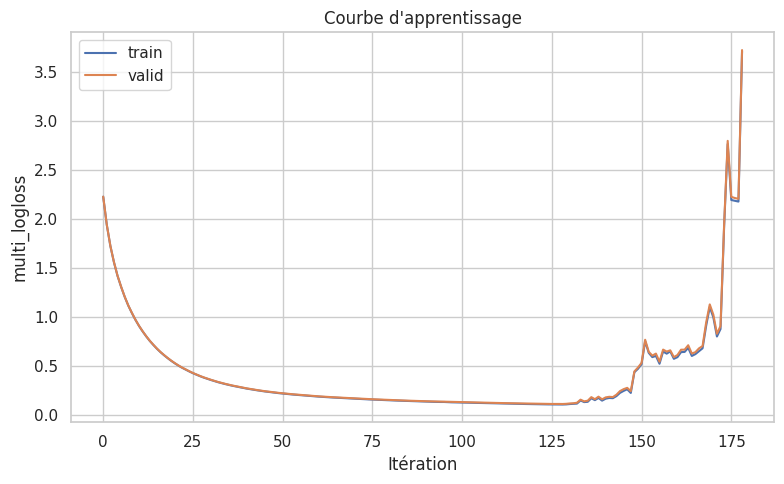

In [ ]:
# Courbe d'apprentissage (loss train vs valid)
plt.figure(figsize=(8, 5))
plt.plot(evals_result["train"]["multi_logloss"], label="train")
plt.plot(evals_result["valid"]["multi_logloss"], label="valid")
plt.xlabel("Itération")
plt.ylabel("multi_logloss")
plt.title("Courbe d'apprentissage")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Évaluation sur le jeu de test

In [ ]:
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = y_pred_proba.argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy       : {acc:.4f}")
print(f"F1-score macro : {f1_macro:.4f}\n")

print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy       : 0.9697
F1-score macro : 0.9686

              precision    recall  f1-score   support

          0L       0.94      0.96      0.95     28743
          0M       0.97      0.98      0.98     28203
          1L       0.97      0.98      0.97     25803
          1M       0.99      0.99      0.99     27803
          2L       0.98      0.95      0.97     28425
          2M       0.99      1.00      0.99     28803
          3L       0.94      0.92      0.93     20699
          3M       0.96      0.95      0.96     13993
          4L       1.00      1.00      1.00     28803
          4M       1.00      1.00      1.00     28803
          5L       0.94      0.93      0.94     28603
          5M       0.99      0.99      0.99     28803
          6L       0.93      0.95      0.94     28803
          6M       1.00      1.00      1.00     28803
          7L       0.91      0.92      0.92     28803
          7M       0.99      0.99      0.99     28803

    accuracy                   

## 11. Matrice de confusion

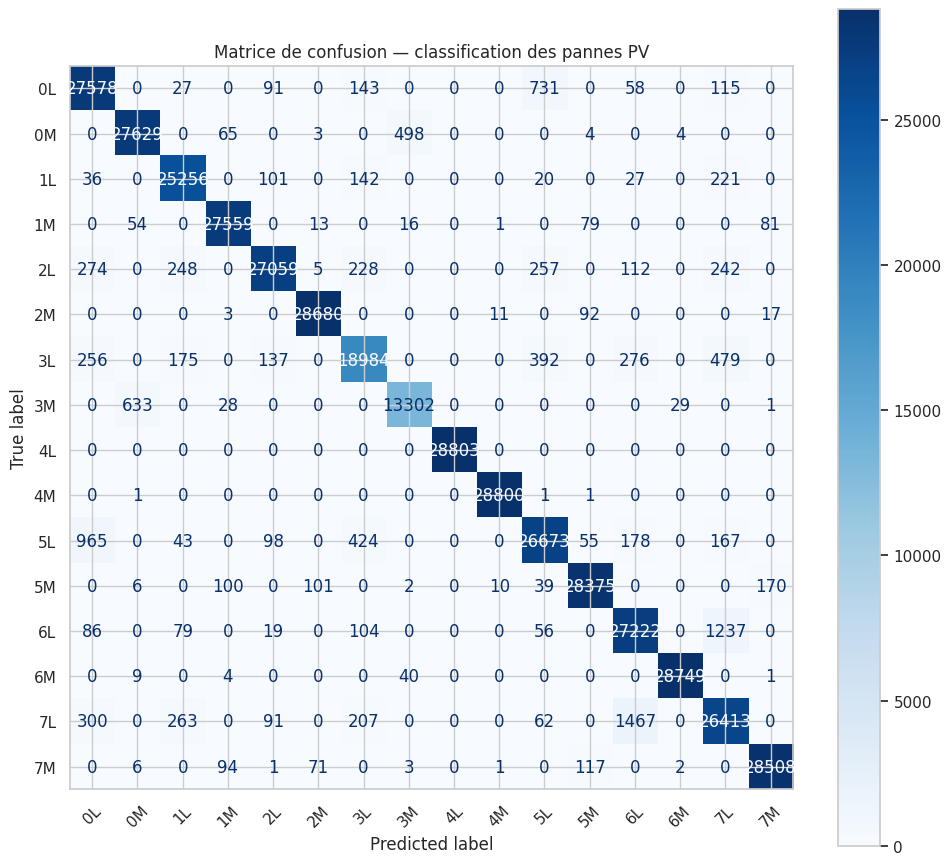

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title("Matrice de confusion — classification des pannes PV")
plt.tight_layout()
plt.show()


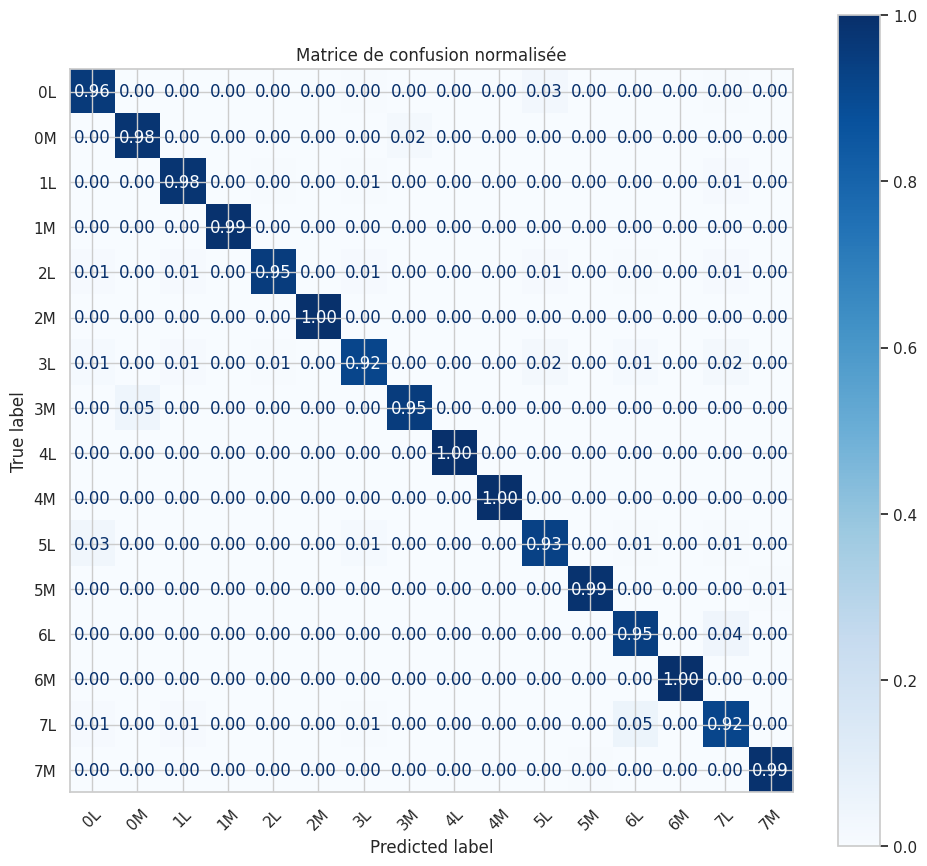

In [ ]:
# Version normalisée (en %) — plus lisible quand les classes sont déséquilibrées
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=True)
plt.title("Matrice de confusion normalisée")
plt.tight_layout()
plt.show()


## 12. Importance des features

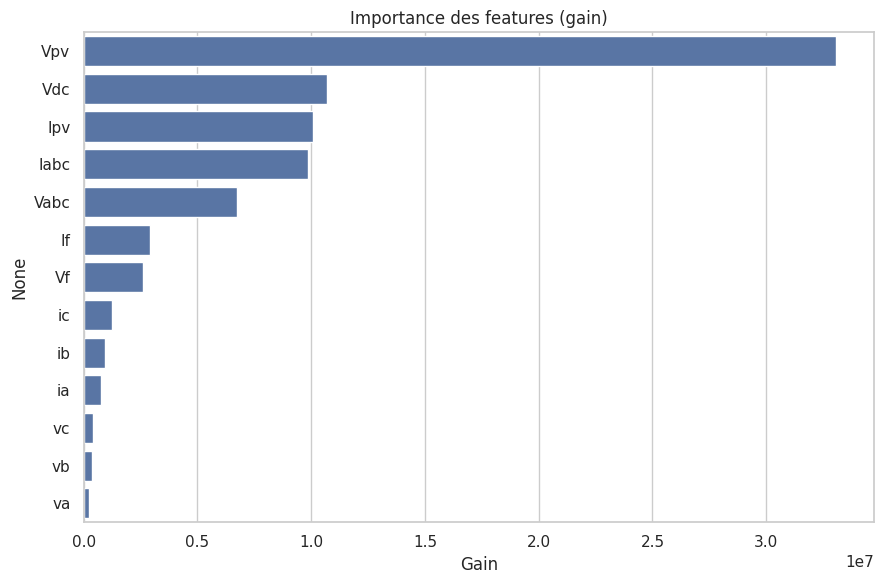

,0
Vpv,3.308227e+07
Vdc,1.067541e+07
Ipv,1.006896e+07
Iabc,9.847869e+06
Vabc,6.740078e+06
If,2.918208e+06
Vf,2.613539e+06
ic,1.244951e+06
ib,9.480189e+05
ia,7.716237e+05


In [ ]:
importance = pd.Series(
    model.feature_importance(importance_type="gain"),
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, orient="h")
plt.title("Importance des features (gain)")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()

importance


## 13. Sauvegarde du modèle sur Drive

In [ ]:
import joblib
import json as _json

model_path = os.path.join(OUTPUT_DIR, "lgbm_pv_fault_model.txt")
model.save_model(model_path)
print("Modèle LightGBM sauvegardé :", model_path)

encoder_path = os.path.join(OUTPUT_DIR, "label_encoder.joblib")
joblib.dump(le, encoder_path)
print("LabelEncoder sauvegardé :", encoder_path)

meta = {
    "feature_cols": feature_cols,
    "classes": list(le.classes_),
    "best_iteration": model.best_iteration,
    "accuracy": float(acc),
    "f1_macro": float(f1_macro),
}
meta_path = os.path.join(OUTPUT_DIR, "metadata.json")
with open(meta_path, "w") as fp:
    _json.dump(meta, fp, indent=2)
print("Métadonnées sauvegardées :", meta_path)


Modèle LightGBM sauvegardé : /content/drive/MyDrive/resultat_projet_panneau_solaire/lgbm_pv_fault_model.txt
LabelEncoder sauvegardé : /content/drive/MyDrive/resultat_projet_panneau_solaire/label_encoder.joblib
Métadonnées sauvegardées : /content/drive/MyDrive/resultat_projet_panneau_solaire/metadata.json


## 14. Recharger le modèle plus tard (exemple)

```python
import lightgbm as lgb
import joblib

model = lgb.Booster(model_file="/content/drive/MyDrive/pv_fault_model/lgbm_pv_fault_model.txt")
le = joblib.load("/content/drive/MyDrive/pv_fault_model/label_encoder.joblib")

proba = model.predict(X_new)
pred_label = le.inverse_transform([proba.argmax(axis=1)[0]])[0]
print(pred_label)  # ex: "7M"
```